In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

IMEI: 869487060202073
V1.0.0.7
V10.1

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\V6N-783.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99651 entries, 0 to 99650
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  99651 non-null  str  
 1   Message  99651 non-null  str  
 2   Status   99651 non-null  str  
dtypes: str(3)
memory usage: 2.3 MB


In [3]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252523    98031
0x252514     1190
0x252513      214
0x252501      108
0x252511      108
Name: count, dtype: int64

In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99651 entries, 0 to 99650
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  99651 non-null  str  
 1   Message  99651 non-null  str  
 2   Status   99651 non-null  str  
 3   Headers  99651 non-null  str  
dtypes: str(4)
memory usage: 3.0 MB


Odometer

In [5]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 1404 entries, 0 to 99650
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             1404 non-null   str  
 1   Message             1404 non-null   str  
 2   Status              1404 non-null   str  
 3   Headers             1404 non-null   str  
 4   Odometer in meters  1404 non-null   int64
 5   Date                1404 non-null   str  
 6   Raw data            1404 non-null   str  
dtypes: int64(1), str(6)
memory usage: 87.8 KB
None


260927020336 -> 0 -> 2721200.0 -> 0x25251300591E480869487060202073003C38402D000029594E0000000700640000000000010002FFFFFFFFFFFF00D5002985B00026092702033600D81245592C8FC2602283C10000005C03941256FFFFFF00001C0000FFFFFF
260927060336 -> 1 -> 2721200.0 -> 0x25251300591E490869487060202073003C38402D00002956510000000700640000000000040003FFFFFFFFFFFF00D5002985B00026092706033600D81245592C8FC2602283C10000005C03941236FFFFFF0000160000FFFFFF
260927100335 -> 2 -> 2721200.0 -> 0x25251300591E4A0869487060202073003C38402D000029564F0000000700640000000000070004FFFFFFFFFFFF00D5002985B00026092710033500D81245592C8FC2602283C10000005C03941208FFFFFF0000110000FFFFFF
260927140336 -> 3 -> 2721200.0 -> 0x25251300591E4B0869487060202073003C38402D00002959510000000700640000000000000000FFFFFFFFFFFF00D5002985B00026092714033600D81245592C8FC2602283C10000005C03931213FFFFFF00002D0000FFFFFF
260927180335 -> 4 -> 2721200.0 -> 0x25251300591E4C0869487060202073003C38402D000029594F0000000700640000000000000000FFFFFFFFFFFF00D5002985B000

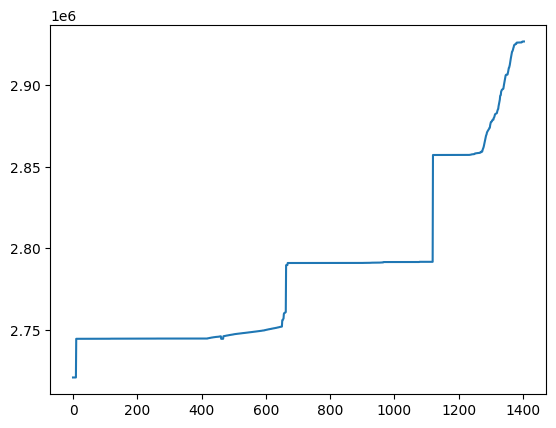

In [6]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [7]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


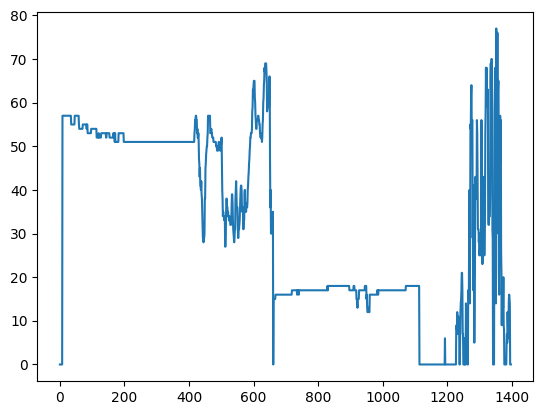

In [8]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historical events

In [9]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 0b10000000)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

print(satellite_connection_indicator)
unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

[0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 128, 0, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128

Satellites Number

In [10]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 1404 entries, 0 to 99650
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         1404 non-null   str  
 1   Message                         1404 non-null   str  
 2   Status                          1404 non-null   str  
 3   Headers                         1404 non-null   str  
 4   Satellites                      1404 non-null   int64
 5   Satellite_connection_indicator  1404 non-null   int64
 6   Raw data                        1404 non-null   str  
 7   date                            1404 non-null   str  
dtypes: int64(2), str(6)
memory usage: 98.7 KB
128 -> 2026-09-27 21:29:04.783 -> 0 -> 0x252514005931F20869487060202073003C38402D00002959800000000000640100000000000000FFFFFFFFFFFF17D5002985B80026092721251982CC000A02CD8267C5A9013A0047009503931398FFFFFF000023FFFFFFFFFF
128 -> 2026-09-27 21:29:04.963 -> 0 -> 0x25251300591

Coordinates

In [11]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 1404 entries, 0 to 99650
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            1404 non-null   str    
 1   Message            1404 non-null   str    
 2   Status             1404 non-null   str    
 3   Headers            1404 non-null   str    
 4   Latitude           1404 non-null   str    
 5   Latitude_decoded   1404 non-null   float64
 6   Longitude          1404 non-null   str    
 7   Longitude_decoded  1404 non-null   float64
 8   Raw data           1404 non-null   str    
 9   Date               1404 non-null   str    
 10  Speed              1404 non-null   int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 131.6 KB
None
260927020336 -> 602283C1 -> -16.39178466796875 -> 592C8FC2 -> -71.58661651611328 0x25251300591E480869487060202073003C38402D000029594E0000000700640000000000010002FFFFFFFFFFFF00D5002985B00026092702033600D81245592C8FC26022

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [ ]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V6N-783.csv')

<class 'pandas.DataFrame'>
Index: 1404 entries, 0 to 99650
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1404 non-null   str  
 1   Message  1404 non-null   str  
 2   Status   1404 non-null   str  
 3   Headers  1404 non-null   str  
dtypes: str(4)
memory usage: 54.8 KB


Ignition

In [13]:
in_outs_df.info()

for i in range(0,in_outs_df.shape[0]):
    length=len(in_outs_df.iloc[i,0])
    if length>16:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])
    else:
        aux_ign=in_outs_df.iloc[i,0][2:3]
        if aux_ign=='1':
            print("Ignition On",in_outs_df.iloc[i,0])
        if aux_ign=='0':
            print("Ignition Off",in_outs_df.iloc[i,0])

<class 'pandas.DataFrame'>
Index: 1402 entries, 0 to 1401
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1402 non-null   str  
 1   date         1402 non-null   str  
 2   raw data     1402 non-null   str  
dtypes: str(3)
memory usage: 43.8 KB
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition Off 0b0
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b100000000
Ignition On 0b1000

Door detection

In [14]:
x='0b0011000000000000' # for 16 bits, len=18

print(len(x),(x[4:6]))

y='0b011000000000000'   # for 15 bits, len=17
print(len(y), (y[3:5]))


18 11
17 11


In [ ]:
in_outs=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\in_outs_V6N-783.csv',sep=',')
in_outs.info()
for i in range(0,in_outs.shape[0]):
    aux=(in_outs.iloc[i,1])
    if len(aux)==18:
        aux_2=(in_outs.iloc[i,1][4:6])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)
    if len(aux)==17:
        aux_2=(in_outs.iloc[i,1][3:5])
        if aux_2=='11':
            print(in_outs.iloc[i,1],len(aux),aux_2)

<class 'pandas.DataFrame'>
RangeIndex: 3378 entries, 0 to 3377
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Unnamed: 0   3378 non-null   int64
 1   in and outs  3378 non-null   str  
 2   date         3378 non-null   int64
 3   raw data     3378 non-null   str  
dtypes: int64(2), str(2)
memory usage: 105.7 KB


Panic detection

In [16]:
unit_.info()

<class 'pandas.DataFrame'>
RangeIndex: 1402 entries, 0 to 1401
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   in and outs  1402 non-null   str  
 1   date         1402 non-null   str  
 2   raw data     1402 non-null   str  
dtypes: str(3)
memory usage: 33.0 KB


In [17]:
for i in range(0,unit_.shape[0]):
    if unit_.iloc[i,2][92:94]=='42':
        print(unit_.iloc[i,2],unit_.iloc[i,1])

iButton

In [18]:
id_button_m=raw_data[raw_data['Headers'].str.contains('0x252523')]
device_id=[]
id_button_date=[]

for i in range(0,id_button_m.shape[0]):
    device_id.append(id_button_m.iloc[i,2][84:100])
    id_button_date.append(id_button_m.iloc[i,2][32:44])
    print(id_button_m.iloc[i,2][84:100],id_button_m.iloc[i,2][32:44])

id_button_m['date']=id_button_date
id_button_m['device_id']=device_id

yymmdd=[]

for i in range(0,id_button_m.shape[0]):
    yymmdd.append(id_button_m.iloc[i,2][32:38])

id_button_m['yymmdd']=yymmdd
id_button_m.info()

B600001F8D2FBD01 260927212429
B600001F8D2FBD01 260927212430
B600001F8D2FBD01 260927212430
B600001F8D2FBD01 260927212431
B600001F8D2FBD01 260927212431
B600001F8D2FBD01 260927212432
B600001F8D2FBD01 260927212432
B600001F8D2FBD01 260927212433
B600001F8D2FBD01 260927212433
B600001F8D2FBD01 260927212434
B600001F8D2FBD01 260927212434
B600001F8D2FBD01 260927212435
B600001F8D2FBD01 260927212435
B600001F8D2FBD01 260927212436
B600001F8D2FBD01 260927212436
B600001F8D2FBD01 260927212437
B600001F8D2FBD01 260927212437
B600001F8D2FBD01 260927212438
B600001F8D2FBD01 260927212438
B600001F8D2FBD01 260927212439
B600001F8D2FBD01 260927212440
B600001F8D2FBD01 260927212440
B600001F8D2FBD01 260927212441
B600001F8D2FBD01 260927212441
B600001F8D2FBD01 260927212442
B600001F8D2FBD01 260927212442
B600001F8D2FBD01 260927212443
B600001F8D2FBD01 260927212443
B600001F8D2FBD01 260927212444
B600001F8D2FBD01 260927212444
B600001F8D2FBD01 260927212445
B600001F8D2FBD01 260927212445
B600001F8D2FBD01 260927212446
B600001F8D

In [19]:
id_button_m['yymmdd'].value_counts()

yymmdd
260928    84286
260927    13745
Name: count, dtype: int64

log de conductores

In [20]:
log=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\corporacion_rico\Drivers Log Report_es.xlsx')
sn='V6N-783'
log_v6n_783=log[log['Unidad'].str.contains(sn)]
log_v6n_783

,Conductor,Unidad,Unnamed: 2,Entrada,Unnamed: 4,Dirección / Landmark,Unnamed: 6,Unnamed: 7,Unnamed: 8,Salida,Unnamed: 10,Dirección / Landmark.1
